In [1]:
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator
import numpy as np
import seaborn as sns
import pysam
import matplotlib.ticker as mticker
from dimelo import parse_bam, plot_enrichment_profile, plot_reads, load_processed, plot_enrichment, export, plot_read_browser, plot_depth_profile

import config, plotting
from utils import track

In [2]:
plt.style.use("plots.mpstyle")

In [3]:
motifs = ["A,0", "GCH,1", "WCG,1"]

Loading data:   0%|          | 0/1189 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1171 [00:00<?, ?it/s]

Loading data:   0%|          | 0/8738 [00:00<?, ?it/s]

Loading data:   0%|          | 0/17476 [00:00<?, ?it/s]

Loading data:   0%|          | 0/2462 [00:00<?, ?it/s]

...

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

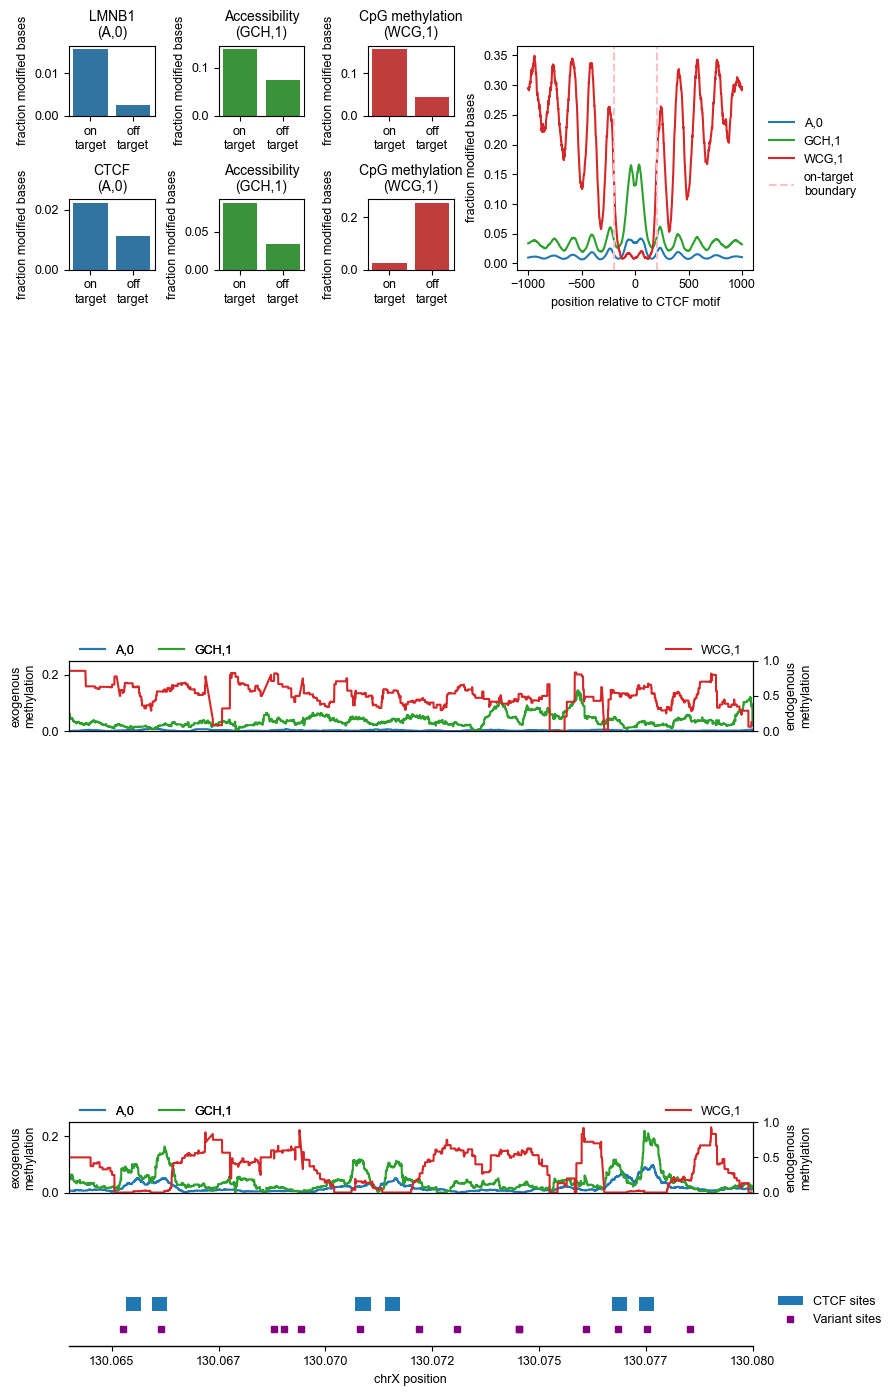

In [8]:
bar_height = 1
bar_width = 2
ctcf_profile_width = 4
full_width = bar_width * len(motifs) + ctcf_profile_width
read_height = 2
profile_height = 1
sites_height = 1

row_1 = [list(itertools.chain(*[[f"{motif}:lmnb1:bar"] * bar_width for motif in motifs])) + ["ctcf:profile"] * ctcf_profile_width] * bar_height
row_2 = [list(itertools.chain(*[[f"{motif}:ctcf:bar"] * bar_width for motif in motifs])) + ["ctcf:profile"] * ctcf_profile_width] * bar_height
row_3 = [["activex:reads"] * full_width] * read_height
row_4 = [["activex:profile"] * full_width] * profile_height
row_5 = [["inactivex:reads"] * full_width] * read_height
row_6 = [["inactivex:profile"] * full_width] * profile_height
row_7 = [["sites"] * full_width] * sites_height
mosaic = row_1 + row_2 + row_3 + row_4 + row_5 + row_6 + row_7
fig, axs_dict = plt.subplot_mosaic(
    mosaic,
    layout="tight",
    figsize = (9, 14)
)


# Panel A
lmnb1_bam_file = config.processed_data_dir / "barcode24.bam"
cLAD = {
    "bed_file": config.processed_data_dir / "cLAD_gold_final_250kb.t2t_chm13v2.bed",
    "motif": "A,0",
    # "id": "cLADs",
    "id": "on\ntarget"
}
ciLAD = {
    "bed_file": config.processed_data_dir / "ciLAD_gold_final_250kb.t2t_chm13v2.bed",
    "motif": "A,0",
    # "id": "ciLADs"
    "id": "off\ntarget"
}
on_target_accessibility = {
    "bed_file": config.processed_data_dir / "gm12878_accessibility.on_target.bed",
    "motif": "GCH,1",
    # "id": "active TSSs"
    "id": "on\ntarget"
}
off_target_accessibility = {
    "bed_file": config.processed_data_dir / "gm12878_accessibility.off_target.bed",
    "motif": "GCH,1",
    # "id": "active TSS\nflanking regions"
    "id": "off\ntarget"
}
on_target_CG = {
    "bed_file": config.processed_data_dir / "gm12878_cpg.on_target.bed",
    "motif": "WCG,1",
    # "id": "inactive TSS\nCpG islands"
    "id": "on\ntarget"
}
off_target_CG = {
    "bed_file": config.processed_data_dir / "gm12878_cpg.off_target.bed",
    "motif": "WCG,1",
    # "id": "active TSS\nCpG islands"
    "id": "off\ntarget"
}
condition_dicts = [cLAD, ciLAD, on_target_accessibility, off_target_accessibility, on_target_CG, off_target_CG]
A_dicts = [cLAD, ciLAD]
GC_dicts = [on_target_accessibility, off_target_accessibility]
CG_dicts = [on_target_CG, off_target_CG]
ax = axs_dict["A,0:lmnb1:bar"]
plot_enrichment.plot_enrichment(
    mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in A_dicts],
    regions_list=[condition_dict["bed_file"] for condition_dict in A_dicts],
    motifs=[condition_dict["motif"] for condition_dict in A_dicts],
    sample_names=[condition_dict["id"] for condition_dict in A_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in A_dicts},
    ax=ax
)
ax.set_title("LMNB1\n(A,0)")
ax = axs_dict["GCH,1:lmnb1:bar"]
plot_enrichment.plot_enrichment(
    mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in GC_dicts],
    regions_list=[condition_dict["bed_file"] for condition_dict in GC_dicts],
    motifs=[condition_dict["motif"] for condition_dict in GC_dicts],
    sample_names=[condition_dict["id"] for condition_dict in GC_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in GC_dicts},
    ax=ax
)
ax.set_title("Accessibility\n(GCH,1)")
ax = axs_dict["WCG,1:lmnb1:bar"]
plot_enrichment.plot_enrichment(
    mod_file_names=[config.processed_data_dir / f"pileup.{lmnb1_bam_file.stem}.{condition_dict['bed_file'].stem}" / "pileup.sorted.bed.gz" for condition_dict in CG_dicts],
    regions_list=[condition_dict["bed_file"] for condition_dict in CG_dicts],
    motifs=[condition_dict["motif"] for condition_dict in CG_dicts],
    sample_names=[condition_dict["id"] for condition_dict in CG_dicts],
    palette = {condition_dict["id"]: plotting.default_palette_map[condition_dict["motif"]] for condition_dict in CG_dicts},
    ax=ax
)
ax.set_title("CpG methylation\n(WCG,1)")

# Panel B
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"
top_ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
ctcf_output_id = f"{ctcf_bam_file.stem}.{top_ctcf_bed_file.stem}"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
ctcf_off_target_bed_file = config.processed_data_dir / "gm12878_ctcf.off_target.bed"

sample_names = ["on\ntarget", "off\ntarget"]
titles = ["CTCF", "Accessibility", "CpG methylation"]
for motif, title in zip(motifs, titles):
    ax = axs_dict[f"{motif}:ctcf:bar"]
    plot_enrichment.by_regions(
        mod_file_name=config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
        regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
        motif=motif,
        sample_names=sample_names,
        palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
        ax=ax
    )
    ax.set_title(f"{title}\n({motif})")


# Panel C
ctcf_main_figure_window_size = 1000
smoothing = 25
ctcf_on_target_window_size = 200
ctcf_off_target_window_size = 1300
ax = axs_dict["ctcf:profile"]
plot_enrichment_profile.by_modification(
    config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
    regions=top_ctcf_bed_file,
    motifs=motifs,
    window_size=ctcf_main_figure_window_size,
    smooth_window=smoothing,
    palette=plotting.default_palette_map,
    ax=ax
)
ax.axvline(-ctcf_on_target_window_size, linestyle="--", color="pink", label="on-target\nboundary")
ax.axvline(ctcf_on_target_window_size, linestyle="--", color="pink")
ax.set_xlabel("position relative to CTCF motif")
ax.legend(title="", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)


# Panel D
# Sites
ctcf_peak_bed_gz_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.sorted.bed.gz"
gm12878_vcf = config.processed_data_dir / "NA12878.chm13v2.vcf.gz"
peaks_tabix = pysam.TabixFile(str(ctcf_peak_bed_gz_file))
variants_tabix = pysam.TabixFile(str(gm12878_vcf))
single_read_plot_center = 130_072_000
single_read_plot_window_size = 8000
single_read_plot_palette = {
    "A,0": "#1F77B4",
    "GCH,1": "#2CA02C",
    "WCG,1": "#D62728",
}

def plot_genomic_region(variants, peaks, start_pos, end_pos,
                        ax,
                        chromosome="chrX",
                        variant_label="Variant sites",
                        peak_label="CTCF ChIP peaks"):

    # --- Peaks: thicker bars, sitting on top ---
    peak_height = 0.2          # was 0.2 -> nice and thick
    peak_y = 0.50               # bottom edge of the bars
    for peak_start, peak_end in peaks:
        width = peak_end - peak_start
        rect = patches.Rectangle((peak_start, peak_y), width, peak_height,
                                 linewidth=0, facecolor='#1F77B4', zorder=3,
                                 label=peak_label if peak_start == peaks[0][0] else "")
        ax.add_patch(rect)

    # --- Variants: row below the peaks ---
    variant_y = 0.25
    for i, variant_pos in enumerate(variants):
        ax.plot(variant_pos, variant_y, 's', color='purple',
                markersize=5, zorder=4,
                label=variant_label if i == 0 else "")

    ax.set_xlim(start_pos, end_pos)
    ax.set_ylim(0, 1.0)         # tightened so the two rows are centered

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.set_yticks([])

    # --- x ticks unchanged ---
    ax.xaxis.set_major_locator(MultipleLocator(2500))
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.3f}')
    )
    ax.set_xlabel(chromosome + " position")
    ax.tick_params(axis='x')

    # --- Legend off-frame (to the right) ---
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
              frameon=False)

peaks_list = []
for peak_line in peaks_tabix.fetch("chrX", single_read_plot_center-single_read_plot_window_size, single_read_plot_center+single_read_plot_window_size):
    peak_fields = peak_line.strip().split('\t')
    peak_start = int(peak_fields[1])
    peak_end = int(peak_fields[2])
    peaks_list.append((peak_start, peak_end))
variant_pos_list = []
for variant_line in variants_tabix.fetch("chrX", single_read_plot_center-single_read_plot_window_size, single_read_plot_center+single_read_plot_window_size):
    variant_fields = variant_line.strip().split('\t')
    variant_pos = int(variant_fields[1])
    variant_pos_list.append(variant_pos)
plot_genomic_region(
    variants=variant_pos_list,
    peaks=peaks_list,
    start_pos=single_read_plot_center - single_read_plot_window_size,
    end_pos=single_read_plot_center + single_read_plot_window_size,
    ax=axs_dict["sites"],
    chromosome="chrX",
    variant_label="Variant sites",
    peak_label="CTCF sites",
)


# Profiles
hp1_ax1 = axs_dict["inactivex:profile"]
hp2_ax1 = axs_dict["activex:profile"]
hp1_ax2 = hp1_ax1.twinx()
hp2_ax2 = hp2_ax1.twinx()
hp1_ax1.set_xlim(single_read_plot_center - single_read_plot_window_size, single_read_plot_center + single_read_plot_window_size)
hp2_ax1.set_xlim(single_read_plot_center - single_read_plot_window_size, single_read_plot_center + single_read_plot_window_size)
for profile_motifs, ylim, hp1_ax, hp2_ax in (
    (["A,0","GCH,1"], (0,0.25), hp1_ax1, hp2_ax1),
    (["WCG,1"], (0,1.0), hp1_ax2, hp2_ax2),
):
    smooth_window = 400
    plot_enrichment_profile.by_modification(
        mod_file_name=config.processed_data_dir / "hp1_chrX_pileup" / "pileup.sorted.bed.gz",
        regions = f"chrX:{single_read_plot_center - single_read_plot_window_size // 2}-{single_read_plot_center + single_read_plot_window_size // 2}",
        motifs=profile_motifs,
        window_size=single_read_plot_window_size,
        relative=False,
        smooth_window=smooth_window,
        palette=single_read_plot_palette,
        ax=hp1_ax,
    )
    hp1_ax.set_ylim(*ylim)
    hp1_ax.legend().remove()
    plot_enrichment_profile.by_modification(
        mod_file_name=config.processed_data_dir / "hp2_chrX_pileup" / "pileup.sorted.bed.gz",
        regions=f"chrX:{single_read_plot_center - single_read_plot_window_size // 2}-{single_read_plot_center + single_read_plot_window_size // 2}",
        motifs=profile_motifs,
        window_size=single_read_plot_window_size,
        relative=False,
        smooth_window=smooth_window,
        palette=single_read_plot_palette,
        ax=hp2_ax,
    )
    hp2_ax.set_ylim(*ylim)
    hp2_ax.legend().remove()
hp1_ax1.set_ylabel("exogenous\nmethylation")
hp1_ax2.set_ylabel("endogenous\nmethylation")
hp2_ax1.set_ylabel("exogenous\nmethylation")
hp2_ax2.set_ylabel("endogenous\nmethylation")

# Get handles and labels from both axes
handles1, labels1 = hp1_ax1.get_legend_handles_labels()
handles2, labels2 = hp1_ax2.get_legend_handles_labels()
# Create left legend (A,0 and GCH,1)
leg_left = hp1_ax1.legend(
    handles1, labels1,
    loc='upper left',
    bbox_to_anchor=(0, 1.4),
    ncol=2,
    frameon=False
)
# Create right legend (WCG,1) and add back the left legend
leg_right = hp1_ax2.legend(
    handles2, labels2,
    loc='upper right',
    bbox_to_anchor=(1, 1.4),
    ncol=1,
    frameon=False
)
# Important: add the left legend back since creating the right one removes it
hp1_ax1.add_artist(leg_left)
# Same for the second subplot
handles1, labels1 = hp2_ax1.get_legend_handles_labels()
handles2, labels2 = hp2_ax2.get_legend_handles_labels()

leg_left2 = hp2_ax1.legend(
    handles1, labels1,
    loc='upper left',
    bbox_to_anchor=(0, 1.4),
    ncol=2,
    frameon=False
)
leg_right2 = hp2_ax2.legend(
    handles2, labels2,
    loc='upper right',
    bbox_to_anchor=(1, 1.4),
    ncol=1,
    frameon=False
)

hp2_ax1.add_artist(leg_left2)

hp1_ax1.set_xticks([])
hp1_ax1.set_xlabel("")
hp2_ax1.set_xticks([])
hp2_ax1.set_xlabel("")

axs_dict["inactivex:reads"].axis("off")
axs_dict["activex:reads"].axis("off")


fig.savefig(config.figure_dir / f"fig2.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close()